# Домашнее задание № 8

### Задание 1 (7 баллов).

На датасете lenta_sample.ru  дообучите две модели - modernbert-base (из семинара) и rumodernbert-base (https://huggingface.co/deepvk/RuModernBERT-base). Оцените разницу в качестве сравнив поклассовые метрики (classification_report)

Для обоих моделей качество должно быть >0.10 по f-мере (прогоните несколько экспериментов если у вас получаются нули, изменяя параметры).
Также для обоих моделей попробуйте дообучать модель и целиком и дообучать только последний слой.
Для RuModernBERT дополнительно сравните модель, которая использует первый вектор (cls токен, как в семинаре), так и усредненный вектор по всем hidden_state, который выдает bert.


### Подзадание на 1 балл
Дообучите любую из моделей, добавляя к BERT основе не только один линейный слой, но и один слой LSTM. Финальное состояние из этого слоя должно подаваться с новый линейный классификационный слой.

In [ ]:
# %pip install torch torchvision torchaudio
%pip install git+https://github.com/huggingface/transformers.git srsly triton

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-zncx2vol
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-zncx2vol
  Resolved https://github.com/huggingface/transformers.git to commit c9ea365a7b56326418769a4ba4682864d407ed63
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.2.0.dev0-py3-none-any.whl size=11420305 sha256=6e587485a864981c0ed54d9abef72f6f2fa781014bcc0f0f84dbc5d83b8fb6e4
  Stored in directory: /tmp/pip-ephem-wheel-cache-6yt1erug/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
# стандартные библиотеки
import os, re
import numpy as np
from time import time
from sklearn.model_selection import train_test_split
import pandas as pd
from collections import Counter
from string import punctuation
import matplotlib.pyplot as plt
%matplotlib inline


import torch
from transformers import AutoModel
from transformers import AutoTokenizer

from tqdm.auto import tqdm
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/lenta_sample.csv')

In [ ]:
data

,url,title,text,topic,tags,date
0,https://lenta.ru/news/2010/12/16/passports/,Московская милиция ужесточила паспортный режим,В Москве после серии массовых беспорядков на н...,Россия,Все,2010/12/16
1,https://lenta.ru/news/2014/05/19/student/,Московского студента ограбили на 6 миллионов р...,Неизвестные вынесли из квартиры московского ст...,Россия,NaN,2014/05/19
2,https://lenta.ru/news/2008/09/27/catch/,В Ставропольском крае обезврежены боевики,"В Ставропольском крае задержаны боевики, котор...",Россия,Все,2008/09/27
3,https://lenta.ru/news/2009/07/23/refuse/,Лужков отказался трудоустраивать китайцев с Че...,"Мэр Москвы Юрий Лужков заявил, что не намерен ...",Россия,Все,2009/07/23
4,https://lenta.ru/news/2012/09/29/factory/,По факту пожара на заводе в Югре заведено дело,Следственный комитет России возбудил уголовное...,Россия,Все,2012/09/29
...,...,...,...,...,...,...
602,https://lenta.ru/news/2014/09/14/pattern/,1914. Выкройки для раненых,"В дополнение к выкройкам белья для раненых, ра...",Библиотека,Первая мировая,2014/09/14
603,https://lenta.ru/news/2014/12/23/christmas/,1914. Немецкие и британские солдаты отметили п...,24 декабря в Бельгии в районе Ипра произошло н...,Библиотека,Первая мировая,2014/12/23
604,https://lenta.ru/news/2014/10/21/dobrovolec/,1914. Польский доброволец-герой,В числе поступивших в нашу армию добровольцев ...,Библиотека,Первая мировая,2014/10/21
605,https://lenta.ru/news/2014/09/18/postoffice/,1914. Письма в действующую армию на деревню де...,За последнее время на имя начальника штаба Вер...,Библиотека,Первая мировая,2014/09/18


In [ ]:
data = data.drop(columns=['url', 'tags', 'date'])

In [ ]:
data.dropna(subset=['topic', 'text'], inplace=True)

In [ ]:
data['text'] = data['title'] + ' ' + data['text']

In [ ]:
data = data.drop(columns=['title'])

In [ ]:
data

,text,topic
0,Московская милиция ужесточила паспортный режим...,Россия
1,Московского студента ограбили на 6 миллионов р...,Россия
2,В Ставропольском крае обезврежены боевики В Ст...,Россия
3,Лужков отказался трудоустраивать китайцев с Че...,Россия
4,По факту пожара на заводе в Югре заведено дело...,Россия
...,...,...
602,1914. Выкройки для раненых В дополнение к вы...,Библиотека
603,1914. Немецкие и британские солдаты отметили п...,Библиотека
604,1914. Польский доброволец-герой В числе поступ...,Библиотека
605,1914. Письма в действующую армию на деревню де...,Библиотека


In [ ]:
data['topic'].value_counts()

,count
topic,
Из жизни,55
Бывший СССР,54
Наука и техника,54
Культура,53
Ценности,45
Дом,45
Интернет и СМИ,44
Бизнес,44
Силовые структуры,40


In [ ]:
data = data.rename(columns={'topic': 'label'})

In [ ]:
model_id = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
tokenizer.encode('Выкройки для раненых' )

[50281,
 22292,
 4141,
 3721,
 1697,
 12007,
 23379,
 31618,
 9160,
 6754,
 5126,
 46070,
 50282]

In [ ]:
encoded = tokenizer.encode('Выкройки для раненых' )
[tokenizer.decode([x]) for x in encoded]

['[CLS]',
 'В',
 'ы',
 'к',
 'р',
 'ой',
 'ки',
 ' для',
 ' р',
 'ан',
 'ен',
 'ых',
 '[SEP]']

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data

In [ ]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, tokenizer, MAX_LEN, texts, targets):

        self.tokenizer = tokenizer
        self.texts = [torch.LongTensor(tokenizer.encode(t)[:MAX_LEN]) for t in texts]
        self.texts = torch.nn.utils.rnn.pad_sequence(self.texts, batch_first=True,
                                                     padding_value=self.tokenizer.pad_token_id)

        self.MAX_LEN = MAX_LEN
        self.length = len(texts)

        self.target = torch.LongTensor(targets)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        ids = self.texts[index]
        y = self.target[index]

        return ids, y

    def preprocess(self, text):
        tokens = text.lower().split()
        tokens = [token.strip(punctuation) for token in tokens]
        tokens = [token for token in tokens if token]
        return tokens

In [ ]:
from sklearn.metrics import f1_score

def train(model, iterator, optimizer, criterion, print_every=1000):

    epoch_loss = []
    epoch_f1 = []

    model.train()

    for i, (texts, ys) in enumerate(iterator):

        optimizer.zero_grad()
        predictions = model(texts.to(device)).squeeze()
        loss = criterion(predictions, ys.to(device))



        loss.backward()
        optimizer.step()
        preds = predictions.detach().to('cpu').numpy().argmax(1).tolist()
        y_true = ys.tolist()

        epoch_loss.append(loss.item())
        epoch_f1.append(f1_score(y_true, preds, average="micro"))

        if not (i+1) % print_every:
            print(f'Loss: {np.mean(epoch_loss)}; F1 measure: {np.mean(epoch_f1)}')

    return np.mean(epoch_f1)


def evaluate(model, iterator, criterion):

    epoch_loss = []
    epoch_f1 = []

    model.eval()
    with torch.no_grad():
        for texts, ys in iterator:

            predictions = model(texts.to(device)).squeeze()
            loss = criterion(predictions, ys.to(device))
            preds = predictions.detach().to('cpu').numpy().argmax(1).tolist()
            y_true = ys.tolist()


            epoch_loss.append(loss.item())
            epoch_f1.append(f1_score(y_true, preds, average="micro"))

    return np.mean(epoch_f1)# / len(iterator)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def predict(model, iterator):

    preds = []

    model.eval()
    with torch.no_grad():
        for texts, ys in iterator:
            predictions = model(texts.to(device)).squeeze()
            ys = predictions.detach().to('cpu').numpy().argmax(1).tolist()
            preds.extend(ys)

    return preds

In [ ]:
MAX_LEN = 512

In [ ]:
texts = data.text.values
id2label = {i:l for i,l in enumerate(set(data.label))}
label2id = {l:i for i,l in id2label.items()}
targets = [label2id[l] for l in data.label]

In [ ]:
train_texts, valid_texts, train_targets, valid_targets = train_test_split(texts, targets, test_size=0.1,random_state=42,stratify=targets)

In [ ]:
training_set = Dataset(tokenizer, MAX_LEN, train_texts, train_targets)
training_generator = torch.utils.data.DataLoader(training_set, batch_size=16, shuffle=True, )
valid_set = Dataset(tokenizer, MAX_LEN, valid_texts, valid_targets)
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=16, shuffle=True)

In [ ]:
import torch.nn as nn

class CLF(nn.Module):

    def __init__(self, pretrained_model, num_classes):
        super().__init__()
        self.tokenizer = tokenizer # токенизатор
        self.pretrained_model = pretrained_model # предобученная модель
        #
        self.drop = nn.Dropout(0.3) # добавим дропаут чтобы не переобучалось
        self.fc = nn.Linear(768, num_classes)
        self.act = nn.LogSoftmax(1)

    def forward(self, texts):

        mask = (texts != tokenizer.pad_token_id).long()

        # прогоняем через BERT
        hidden = self.pretrained_model(texts, attention_mask=mask)[0]

        # берем самое первое состояние и применяем к нему линейный слой и активацию
        dense_outputs=self.fc(self.drop(hidden[:,0] ))
        outputs=self.act(dense_outputs)

        return outputs

**modernbert-base последний слой**

In [ ]:
model_id = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model_bert = AutoModel.from_pretrained(model_id)

for param in model_bert.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CLF(model_bert, len(label2id))
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.NLLLoss()
model = model.to(device)
criterion = criterion.to(device)

In [ ]:
print("Percentage of trainable params:")
print('{0:.10f}'.format(sum(p.numel() for p in model.parameters() if p.requires_grad)/sum(p.numel() for p in model.parameters())))

Percentage of trainable params:
0.0000877222


In [ ]:
f1s = []
f1s_eval = []

for i in range(40):
    print(i)
    f1s.append(train(model, training_generator, optimizer, criterion, 2000))
    evl = evaluate(model, valid_generator, criterion)
    print('Eval - ', evl)
    f1s_eval.append(evl)

0
Eval -  0.11260775862068965
1
Eval -  0.11584051724137931
2
Eval -  0.14870689655172414
3
Eval -  0.09536637931034483
4
Eval -  0.11745689655172414
5
Eval -  0.1783405172413793
6
Eval -  0.12984913793103448
7
Eval -  0.1627155172413793
8
Eval -  0.17995689655172414
9
Eval -  0.15625
10
Eval -  0.1627155172413793
11
Eval -  0.1314655172413793
12
Eval -  0.12984913793103448
13
Eval -  0.1783405172413793
14
Eval -  0.1831896551724138
15
Eval -  0.15948275862068967
16
Eval -  0.16594827586206895
17
Eval -  0.16594827586206895
18
Eval -  0.18157327586206895
19
Eval -  0.1314655172413793
20
Eval -  0.11584051724137931
21
Eval -  0.1939655172413793
22
Eval -  0.19558189655172414
23
Eval -  0.1783405172413793
24
Eval -  0.1939655172413793
25
Eval -  0.16594827586206895
26
Eval -  0.20204741379310345
27
Eval -  0.2300646551724138
28
Eval -  0.22844827586206895
29
Eval -  0.1939655172413793
30
Eval -  0.23329741379310345
31
Eval -  0.2144396551724138
32
Eval -  0.21282327586206895
33
Eval -  0

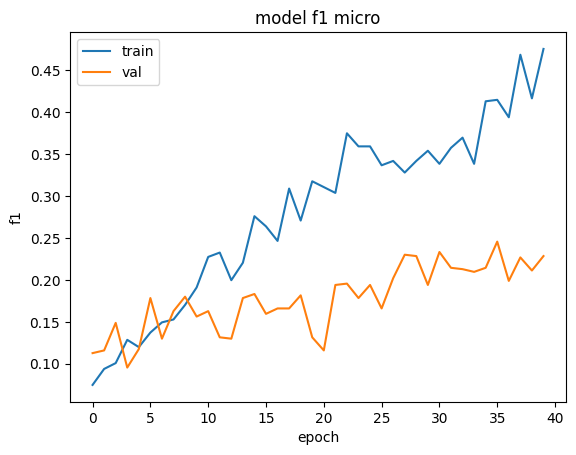

In [ ]:
plt.plot(f1s)
plt.plot(f1s_eval)
plt.title('model f1 micro')
plt.ylabel('f1')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=32, shuffle=False)
preds = predict(model, valid_generator)

In [ ]:
print(classification_report(valid_targets, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         4
           2       0.33      0.60      0.43         5
           3       0.30      0.75      0.43         4
           4       0.11      0.20      0.14         5
           5       0.00      0.00      0.00         6
           6       0.20      0.25      0.22         4
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         3
          10       0.33      0.40      0.36         5
          11       0.00      0.00      0.00         1
          12       0.50      0.33      0.40         6
          13       1.00      0.20      0.33         5
          14       0.00      0.00      0.00         4
          15       1.00      1.00      1.00         1
          16       0.00      0.00      0.00         3

    accuracy              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**modernbert-base целиком**

In [ ]:
model_id = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model_bert = AutoModel.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CLF(model_bert, len(label2id))
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.NLLLoss()
model = model.to(device)
criterion = criterion.to(device)

In [ ]:
print("Percentage of trainable params:")
print('{0:.10f}'.format(sum(p.numel() for p in model.parameters() if p.requires_grad)/sum(p.numel() for p in model.parameters())))


Percentage of trainable params:
1.0000000000


In [ ]:
f1s = []
f1s_eval = []

for i in range(25):
    print(i)
    f1s.append(train(model, training_generator, optimizer, criterion, 2000))
    evl = evaluate(model, valid_generator, criterion)
    print('Eval - ', evl)
    f1s_eval.append(evl)

0
Eval -  0.06610576923076923
1
Eval -  0.078125
2
Eval -  0.09375
3
Eval -  0.06610576923076923
4
Eval -  0.14423076923076922
5
Eval -  0.1045673076923077
6
Eval -  0.19471153846153846
7
Eval -  0.15985576923076922
8
Eval -  0.2295673076923077
9
Eval -  0.1983173076923077
10
Eval -  0.2451923076923077
11
Eval -  0.20673076923076922
12
Eval -  0.21033653846153846
13
Eval -  0.2295673076923077
14
Eval -  0.28365384615384615
15
Eval -  0.1983173076923077
16
Eval -  0.24158653846153846
17
Eval -  0.2536057692307692
18
Eval -  0.2451923076923077
19
Eval -  0.24879807692307693
20
Eval -  0.25721153846153844
21
Eval -  0.24158653846153846
22
Eval -  0.2800480769230769
23
Eval -  0.24879807692307693
24
Eval -  0.2716346153846154


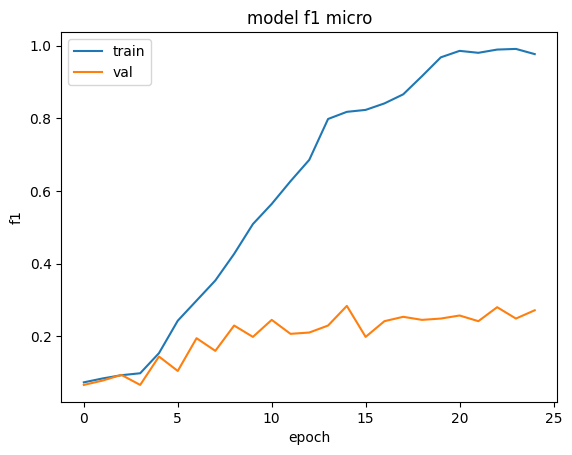

In [ ]:
plt.plot(f1s)
plt.plot(f1s_eval)
plt.title('model f1 micro')
plt.ylabel('f1')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=16, shuffle=False)
preds = predict(model, valid_generator)

In [ ]:
print(classification_report(valid_targets, preds))

              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00         1
           3       0.33      0.20      0.25         5
           4       0.00      0.00      0.00         3
           5       0.25      0.20      0.22         5
           6       0.00      0.00      0.00         3
           7       0.33      0.50      0.40         4
           8       0.00      0.00      0.00         1
           9       0.33      0.40      0.36         5
          10       0.00      0.00      0.00         1
          11       1.00      0.33      0.50         6
          12       0.67      0.50      0.57         4
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         4
          15       0.25      0.40      0.31         5
          16       0.00      0.00      0.00         4

    accuracy              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**rumodernbert-base последний слой**

In [1]:
# %pip install torch torchvision torchaudio
%pip install git+https://github.com/huggingface/transformers.git srsly triton

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-zwyscy19
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-zwyscy19
  Resolved https://github.com/huggingface/transformers.git to commit c9ea365a7b56326418769a4ba4682864d407ed63
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.2.0.dev0-py3-none-any.whl size=11420305 sha256=a0e567576b90c5576918f75bb3d8a0523f681026c93caadbeb9077ebb6793fe8
  Stored in directory: /tmp/pip-ephem-wheel-cache-o1y2i2zh/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
# стандартные библиотеки
import os, re
import numpy as np
from time import time
from sklearn.model_selection import train_test_split
import pandas as pd
from collections import Counter
from string import punctuation
import matplotlib.pyplot as plt
%matplotlib inline


import torch
from transformers import AutoModel
from transformers import AutoTokenizer

from tqdm.auto import tqdm
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/lenta_sample.csv')

In [5]:
data = data.drop(columns=['url', 'tags', 'date'])
data.dropna(subset=['topic', 'text'], inplace=True)
data['text'] = data['title'] + ' ' + data['text']
data = data.drop(columns=['title'])
data = data.rename(columns={'topic': 'label'})

In [6]:
model_id = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

The `reference_compile` argument is deprecated and will be removed in `transformers v5.2.0`Use `torch.compile()` directly on the model instead.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
encoded = tokenizer.encode('Выкройки для раненых' )
[tokenizer.decode([x]) for x in encoded]

['[CLS]', 'Вы', 'крой', 'ки', ' для', ' ране', 'ных', '[SEP]']

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data

In [6]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, tokenizer, MAX_LEN, texts, targets):

        self.tokenizer = tokenizer
        self.texts = [torch.LongTensor(tokenizer.encode(t)[:MAX_LEN]) for t in texts]
        self.texts = torch.nn.utils.rnn.pad_sequence(self.texts, batch_first=True,
                                                     padding_value=self.tokenizer.pad_token_id)

        self.MAX_LEN = MAX_LEN
        self.length = len(texts)

        self.target = torch.LongTensor(targets)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        ids = self.texts[index]
        y = self.target[index]

        return ids, y

    def preprocess(self, text):
        tokens = text.lower().split()
        tokens = [token.strip(punctuation) for token in tokens]
        tokens = [token for token in tokens if token]
        return tokens

In [7]:
from sklearn.metrics import f1_score

def train(model, iterator, optimizer, criterion, print_every=1000):

    epoch_loss = []
    epoch_f1 = []

    model.train()

    for i, (texts, ys) in enumerate(iterator):

        optimizer.zero_grad()
        predictions = model(texts.to(device)).squeeze()
        loss = criterion(predictions, ys.to(device))



        loss.backward()
        optimizer.step()
        preds = predictions.detach().to('cpu').numpy().argmax(1).tolist()
        y_true = ys.tolist()

        epoch_loss.append(loss.item())
        epoch_f1.append(f1_score(y_true, preds, average="micro"))

        if not (i+1) % print_every:
            print(f'Loss: {np.mean(epoch_loss)}; F1 measure: {np.mean(epoch_f1)}')

    return np.mean(epoch_f1)


def evaluate(model, iterator, criterion):

    epoch_loss = []
    epoch_f1 = []

    model.eval()
    with torch.no_grad():
        for texts, ys in iterator:

            predictions = model(texts.to(device)).squeeze()
            loss = criterion(predictions, ys.to(device))
            preds = predictions.detach().to('cpu').numpy().argmax(1).tolist()
            y_true = ys.tolist()


            epoch_loss.append(loss.item())
            epoch_f1.append(f1_score(y_true, preds, average="micro"))

    return np.mean(epoch_f1)# / len(iterator)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
def predict(model, iterator):

    preds = []

    model.eval()
    with torch.no_grad():
        for texts, ys in iterator:
            predictions = model(texts.to(device)).squeeze()
            ys = predictions.detach().to('cpu').numpy().argmax(1).tolist()
            preds.extend(ys)

    return preds

In [10]:
MAX_LEN = 512

In [12]:
texts = data.text.values
id2label = {i:l for i,l in enumerate(set(data.label))}
label2id = {l:i for i,l in id2label.items()}
targets = [label2id[l] for l in data.label]

In [13]:
train_texts, valid_texts, train_targets, valid_targets = train_test_split(texts, targets, test_size=0.2,random_state=42,stratify=targets)

In [16]:
training_set = Dataset(tokenizer, MAX_LEN, train_texts, train_targets)
training_generator = torch.utils.data.DataLoader(training_set, batch_size=128, shuffle=True, )
valid_set = Dataset(tokenizer, MAX_LEN, valid_texts, valid_targets)
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=128, shuffle=True)

In [15]:
import torch.nn as nn

class CLF(nn.Module):

    def __init__(self, pretrained_model, num_classes):
        super().__init__()
        self.tokenizer = tokenizer # токенизатор
        self.pretrained_model = pretrained_model # предобученная модель
        #
        self.drop = nn.Dropout(0.3) # добавим дропаут чтобы не переобучалось
        self.fc = nn.Linear(768, num_classes)
        self.act = nn.LogSoftmax(1)

    def forward(self, texts):

        mask = (texts != tokenizer.pad_token_id).long()

        # прогоняем через BERT
        hidden = self.pretrained_model(texts, attention_mask=mask)[0]

        # берем самое первое состояние и применяем к нему линейный слой и активацию
        dense_outputs=self.fc(self.drop(hidden[:,0] ))
        outputs=self.act(dense_outputs)

        return outputs

In [22]:
model_id = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model_bert = AutoModel.from_pretrained(model_id)

for param in model_bert.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CLF(model_bert, len(label2id))
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.NLLLoss()
model = model.to(device)
criterion = criterion.to(device)

In [24]:
print("Percentage of trainable params:")
print('{0:.10f}'.format(sum(p.numel() for p in model.parameters() if p.requires_grad)/sum(p.numel() for p in model.parameters())))

Percentage of trainable params:
0.0000877222


In [25]:
f1s = []
f1s_eval = []

for i in range(40):
    print(i)
    f1s.append(train(model, training_generator, optimizer, criterion, 2000))
    evl = evaluate(model, valid_generator, criterion)
    print('Eval - ', evl)
    f1s_eval.append(evl)

0
Eval -  0.10655737704918032
1
Eval -  0.10655737704918032
2
Eval -  0.09836065573770492
3
Eval -  0.09836065573770492
4
Eval -  0.10655737704918032
5
Eval -  0.12295081967213115
6
Eval -  0.13114754098360656
7
Eval -  0.13934426229508196
8
Eval -  0.1557377049180328
9
Eval -  0.13934426229508196
10
Eval -  0.16393442622950818
11
Eval -  0.1721311475409836
12
Eval -  0.18032786885245902
13
Eval -  0.18032786885245902
14
Eval -  0.1885245901639344
15
Eval -  0.18032786885245902
16
Eval -  0.1885245901639344
17
Eval -  0.18032786885245902
18
Eval -  0.1885245901639344
19
Eval -  0.1885245901639344
20
Eval -  0.1885245901639344
21
Eval -  0.19672131147540983
22
Eval -  0.19672131147540983
23
Eval -  0.19672131147540983
24
Eval -  0.19672131147540983
25
Eval -  0.19672131147540983
26
Eval -  0.19672131147540983
27
Eval -  0.1885245901639344
28
Eval -  0.19672131147540983
29
Eval -  0.20491803278688525
30
Eval -  0.19672131147540983
31
Eval -  0.1885245901639344
32
Eval -  0.18852459016393

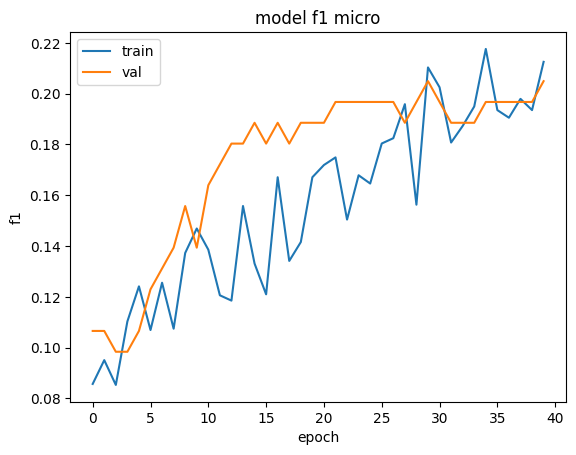

In [26]:
plt.plot(f1s)
plt.plot(f1s_eval)
plt.title('model f1 micro')
plt.ylabel('f1')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [27]:
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=128, shuffle=False)
preds = predict(model, valid_generator)

In [28]:
print(classification_report(valid_targets, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         2
           3       0.11      0.64      0.19        11
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00        11
           6       0.43      0.27      0.33        11
           7       1.00      0.11      0.20         9
           8       0.00      0.00      0.00         6
           9       0.54      0.78      0.64         9
          10       0.00      0.00      0.00         5
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         6
          14       0.18      0.55      0.27        11
          15       1.00      0.12      0.22         8
          16       0.00      0.00      0.00         9

    accuracy              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**rumodernbert-base целиком**

In [2]:
model_id = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model_bert = AutoModel.from_pretrained(model_id)

NameError: name 'AutoTokenizer' is not defined

In [14]:
training_set = Dataset(tokenizer, MAX_LEN, train_texts, train_targets)
training_generator = torch.utils.data.DataLoader(training_set, batch_size=16, shuffle=True, )
valid_set = Dataset(tokenizer, MAX_LEN, valid_texts, valid_targets)
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=16, shuffle=True)

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CLF(model_bert, len(label2id))
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.NLLLoss()
model = model.to(device)
criterion = criterion.to(device)

In [19]:
print("Percentage of trainable params:")
print('{0:.10f}'.format(sum(p.numel() for p in model.parameters() if p.requires_grad)/sum(p.numel() for p in model.parameters())))


Percentage of trainable params:
1.0000000000


In [20]:
f1s = []
f1s_eval = []

for i in range(25):
    print(i)
    f1s.append(train(model, training_generator, optimizer, criterion, 2000))
    evl = evaluate(model, valid_generator, criterion)
    print('Eval - ', evl)
    f1s_eval.append(evl)

0
Eval -  0.0828125
1
Eval -  0.0859375
2
Eval -  0.1609375
3
Eval -  0.1
4
Eval -  0.1375
5
Eval -  0.1859375
6
Eval -  0.18125
7
Eval -  0.2171875
8
Eval -  0.3796875
9
Eval -  0.3390625
10
Eval -  0.4125
11
Eval -  0.3859375
12
Eval -  0.35
13
Eval -  0.425
14
Eval -  0.38125
15
Eval -  0.3890625
16
Eval -  0.4078125
17
Eval -  0.4328125
18
Eval -  0.4171875
19
Eval -  0.425
20
Eval -  0.434375
21
Eval -  0.4421875
22
Eval -  0.4375
23
Eval -  0.4359375
24
Eval -  0.440625


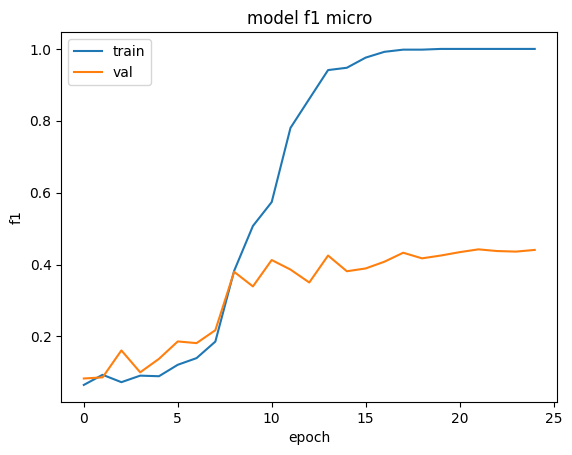

In [21]:
plt.plot(f1s)
plt.plot(f1s_eval)
plt.title('model f1 micro')
plt.ylabel('f1')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [22]:
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=16, shuffle=False)
preds = predict(model, valid_generator)

In [23]:
print(classification_report(valid_targets, preds))

              precision    recall  f1-score   support

           0       0.86      0.55      0.67        11
           1       0.50      0.50      0.50         2
           2       0.29      0.22      0.25         9
           3       0.86      0.67      0.75         9
           4       0.14      0.33      0.20         3
           5       0.75      0.27      0.40        11
           6       1.00      0.33      0.50         6
           7       0.75      0.67      0.71         9
           8       0.38      0.38      0.38         8
           9       0.27      0.44      0.33         9
          10       0.00      0.00      0.00         1
          11       0.43      0.27      0.33        11
          12       0.88      0.88      0.88         8
          13       1.00      0.33      0.50         3
          14       0.17      0.40      0.24         5
          15       1.00      0.55      0.71        11
          16       0.06      0.17      0.08         6

    accuracy              

**rumodernbert-base целиком hidden_state**

In [1]:
# %pip install torch torchvision torchaudio
%pip install git+https://github.com/huggingface/transformers.git srsly triton

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-qrk78gi4
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-qrk78gi4
  Resolved https://github.com/huggingface/transformers.git to commit c9ea365a7b56326418769a4ba4682864d407ed63
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.2.0.dev0-py3-none-any.whl size=11420305 sha256=ececea4a92617f3d61f4c19e4e3a19106d19c2da518dd08e6c1dba6d9fa40ea8
  Stored in directory: /tmp/pip-ephem-wheel-cache-vq_vbg6t/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data

In [3]:
# стандартные библиотеки
import os, re
import numpy as np
from time import time
from sklearn.model_selection import train_test_split
import pandas as pd
from collections import Counter
from string import punctuation
import matplotlib.pyplot as plt
%matplotlib inline


import torch
from transformers import AutoModel
from transformers import AutoTokenizer

from tqdm.auto import tqdm
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv('/content/drive/MyDrive/lenta_sample.csv')

In [6]:
data = data.drop(columns=['url', 'tags', 'date'])
data.dropna(subset=['topic', 'text'], inplace=True)
data['text'] = data['title'] + ' ' + data['text']
data = data.drop(columns=['title'])
data = data.rename(columns={'topic': 'label'})

In [7]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, tokenizer, MAX_LEN, texts, targets):

        self.tokenizer = tokenizer
        self.texts = [torch.LongTensor(tokenizer.encode(t)[:MAX_LEN]) for t in texts]
        self.texts = torch.nn.utils.rnn.pad_sequence(self.texts, batch_first=True,
                                                     padding_value=self.tokenizer.pad_token_id)

        self.MAX_LEN = MAX_LEN
        self.length = len(texts)

        self.target = torch.LongTensor(targets)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        ids = self.texts[index]
        y = self.target[index]

        return ids, y

    def preprocess(self, text):
        tokens = text.lower().split()
        tokens = [token.strip(punctuation) for token in tokens]
        tokens = [token for token in tokens if token]
        return tokens

In [8]:
from sklearn.metrics import f1_score

def train(model, iterator, optimizer, criterion, print_every=1000):

    epoch_loss = []
    epoch_f1 = []

    model.train()

    for i, (texts, ys) in enumerate(iterator):

        optimizer.zero_grad()
        predictions = model(texts.to(device)).squeeze()
        loss = criterion(predictions, ys.to(device))



        loss.backward()
        optimizer.step()
        preds = predictions.detach().to('cpu').numpy().argmax(1).tolist()
        y_true = ys.tolist()

        epoch_loss.append(loss.item())
        epoch_f1.append(f1_score(y_true, preds, average="micro"))

        if not (i+1) % print_every:
            print(f'Loss: {np.mean(epoch_loss)}; F1 measure: {np.mean(epoch_f1)}')

    return np.mean(epoch_f1)


def evaluate(model, iterator, criterion):

    epoch_loss = []
    epoch_f1 = []

    model.eval()
    with torch.no_grad():
        for texts, ys in iterator:

            predictions = model(texts.to(device)).squeeze()
            loss = criterion(predictions, ys.to(device))
            preds = predictions.detach().to('cpu').numpy().argmax(1).tolist()
            y_true = ys.tolist()


            epoch_loss.append(loss.item())
            epoch_f1.append(f1_score(y_true, preds, average="micro"))

    return np.mean(epoch_f1)# / len(iterator)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
def predict(model, iterator):

    preds = []

    model.eval()
    with torch.no_grad():
        for texts, ys in iterator:
            predictions = model(texts.to(device)).squeeze()
            ys = predictions.detach().to('cpu').numpy().argmax(1).tolist()
            preds.extend(ys)

    return preds

In [11]:
MAX_LEN = 512

In [12]:
texts = data.text.values
id2label = {i:l for i,l in enumerate(set(data.label))}
label2id = {l:i for i,l in id2label.items()}
targets = [label2id[l] for l in data.label]

In [14]:
train_texts, valid_texts, train_targets, valid_targets = train_test_split(texts, targets, test_size=0.2,random_state=42,stratify=targets)

In [13]:
model_id = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model_bert = AutoModel.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

The `reference_compile` argument is deprecated and will be removed in `transformers v5.2.0`Use `torch.compile()` directly on the model instead.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
training_set = Dataset(tokenizer, MAX_LEN, train_texts, train_targets)
training_generator = torch.utils.data.DataLoader(training_set, batch_size=16, shuffle=True, )
valid_set = Dataset(tokenizer, MAX_LEN, valid_texts, valid_targets)
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=16, shuffle=True)

In [16]:
import torch.nn as nn

class CLFMeanPooling(nn.Module):
    def __init__(self, pretrained_model, num_classes):
        super().__init__()
        self.pretrained_model = pretrained_model
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(768, num_classes)
        self.act = nn.LogSoftmax(dim=1)

    def forward(self, texts):
        mask = (texts != tokenizer.pad_token_id).long()
        hidden = self.pretrained_model(texts, attention_mask=mask).last_hidden_state
        masked_hidden = hidden * mask.unsqueeze(-1)
        summed = masked_hidden.sum(dim=1)
        lengths = mask.sum(dim=1, keepdim=True).float().clamp(min=1.0)
        pooled = summed / lengths
        outputs = self.act(self.fc(self.drop(pooled)))
        return outputs

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CLFMeanPooling(model_bert, len(label2id))
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.NLLLoss()
model = model.to(device)
criterion = criterion.to(device)

In [18]:
print("Percentage of trainable params:")
print('{0:.10f}'.format(sum(p.numel() for p in model.parameters() if p.requires_grad)/sum(p.numel() for p in model.parameters())))

Percentage of trainable params:
1.0000000000


In [19]:
f1s = []
f1s_eval = []

for i in range(25):
    print(i)
    f1s.append(train(model, training_generator, optimizer, criterion, 2000))
    evl = evaluate(model, valid_generator, criterion)
    print('Eval - ', evl)
    f1s_eval.append(evl)

0
Eval -  0.465625
1
Eval -  0.625
2
Eval -  0.5578125
3
Eval -  0.6515625
4
Eval -  0.709375
5
Eval -  0.68125
6
Eval -  0.696875
7
Eval -  0.68125
8
Eval -  0.6625
9
Eval -  0.66875
10
Eval -  0.69375
11
Eval -  0.7109375
12
Eval -  0.70625
13
Eval -  0.7203125
14
Eval -  0.725
15
Eval -  0.7203125
16
Eval -  0.7078125
17
Eval -  0.7078125
18
Eval -  0.7125
19
Eval -  0.703125
20
Eval -  0.7078125
21
Eval -  0.7078125
22
Eval -  0.7078125
23
Eval -  0.703125
24
Eval -  0.721875


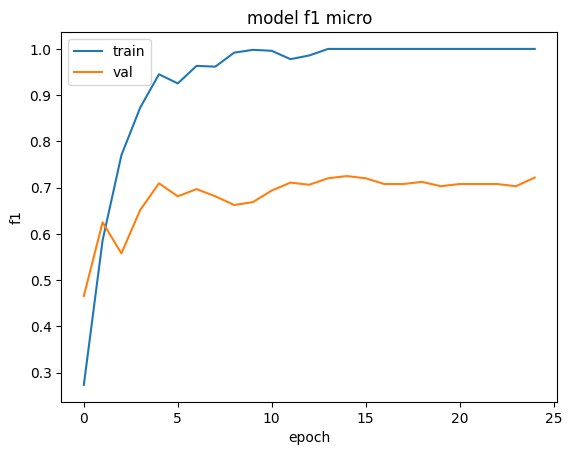

In [20]:
plt.plot(f1s)
plt.plot(f1s_eval)
plt.title('model f1 micro')
plt.ylabel('f1')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [21]:
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=16, shuffle=False)
preds = predict(model, valid_generator)

In [22]:
print(classification_report(valid_targets, preds))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         9
           1       1.00      1.00      1.00         1
           2       0.86      0.67      0.75         9
           3       0.00      0.00      0.00         6
           4       0.83      0.62      0.71         8
           5       0.44      0.67      0.53         6
           6       0.50      0.80      0.62         5
           7       1.00      1.00      1.00         8
           8       0.89      0.73      0.80        11
           9       0.88      0.78      0.82         9
          10       0.67      1.00      0.80         2
          11       1.00      1.00      1.00         3
          12       0.80      0.73      0.76        11
          13       0.64      0.82      0.72        11
          14       0.83      0.45      0.59        11
          15       0.00      0.00      0.00         3
          16       0.57      0.89      0.70         9

    accuracy              

**rumodernbert-base + LSTM**

In [1]:
# %pip install torch torchvision torchaudio
%pip install git+https://github.com/huggingface/transformers.git srsly triton

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-2np8qw6e
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-2np8qw6e
  Resolved https://github.com/huggingface/transformers.git to commit c9ea365a7b56326418769a4ba4682864d407ed63
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.2.0.dev0-py3-none-any.whl size=11420305 sha256=6e14489fcfaff268daecbb69a34a5cf3720e1f6cc3fa5cf9a30a7be274a567b3
  Stored in directory: /tmp/pip-ephem-wheel-cache-tbswqx6v/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
# стандартные библиотеки
import os, re
import numpy as np
from time import time
from sklearn.model_selection import train_test_split
import pandas as pd
from collections import Counter
from string import punctuation
import matplotlib.pyplot as plt
%matplotlib inline


import torch
from transformers import AutoModel
from transformers import AutoTokenizer

from tqdm.auto import tqdm
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/lenta_sample.csv')

In [5]:
data = data.drop(columns=['url', 'tags', 'date'])
data.dropna(subset=['topic', 'text'], inplace=True)
data['text'] = data['title'] + ' ' + data['text']
data = data.drop(columns=['title'])
data = data.rename(columns={'topic': 'label'})

In [6]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, tokenizer, MAX_LEN, texts, targets):

        self.tokenizer = tokenizer
        self.texts = [torch.LongTensor(tokenizer.encode(t)[:MAX_LEN]) for t in texts]
        self.texts = torch.nn.utils.rnn.pad_sequence(self.texts, batch_first=True,
                                                     padding_value=self.tokenizer.pad_token_id)

        self.MAX_LEN = MAX_LEN
        self.length = len(texts)

        self.target = torch.LongTensor(targets)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        ids = self.texts[index]
        y = self.target[index]

        return ids, y

    def preprocess(self, text):
        tokens = text.lower().split()
        tokens = [token.strip(punctuation) for token in tokens]
        tokens = [token for token in tokens if token]
        return tokens

In [7]:
from sklearn.metrics import f1_score

def train(model, iterator, optimizer, criterion, print_every=1000):

    epoch_loss = []
    epoch_f1 = []

    model.train()

    for i, (texts, ys) in enumerate(iterator):

        optimizer.zero_grad()
        predictions = model(texts.to(device)).squeeze()
        loss = criterion(predictions, ys.to(device))



        loss.backward()
        optimizer.step()
        preds = predictions.detach().to('cpu').numpy().argmax(1).tolist()
        y_true = ys.tolist()

        epoch_loss.append(loss.item())
        epoch_f1.append(f1_score(y_true, preds, average="micro"))

        if not (i+1) % print_every:
            print(f'Loss: {np.mean(epoch_loss)}; F1 measure: {np.mean(epoch_f1)}')

    return np.mean(epoch_f1)


def evaluate(model, iterator, criterion):

    epoch_loss = []
    epoch_f1 = []

    model.eval()
    with torch.no_grad():
        for texts, ys in iterator:

            predictions = model(texts.to(device)).squeeze()
            loss = criterion(predictions, ys.to(device))
            preds = predictions.detach().to('cpu').numpy().argmax(1).tolist()
            y_true = ys.tolist()


            epoch_loss.append(loss.item())
            epoch_f1.append(f1_score(y_true, preds, average="micro"))

    return np.mean(epoch_f1)# / len(iterator)

In [8]:
def predict(model, iterator):

    preds = []

    model.eval()
    with torch.no_grad():
        for texts, ys in iterator:
            predictions = model(texts.to(device)).squeeze()
            ys = predictions.detach().to('cpu').numpy().argmax(1).tolist()
            preds.extend(ys)

    return preds

In [9]:
MAX_LEN = 512

In [10]:
texts = data.text.values
id2label = {i:l for i,l in enumerate(set(data.label))}
label2id = {l:i for i,l in id2label.items()}
targets = [label2id[l] for l in data.label]

In [11]:
train_texts, valid_texts, train_targets, valid_targets = train_test_split(texts, targets, test_size=0.2,random_state=42,stratify=targets)

In [12]:
model_id = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model_bert = AutoModel.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

The `reference_compile` argument is deprecated and will be removed in `transformers v5.2.0`Use `torch.compile()` directly on the model instead.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
training_set = Dataset(tokenizer, MAX_LEN, train_texts, train_targets)
training_generator = torch.utils.data.DataLoader(training_set, batch_size=16, shuffle=True, )
valid_set = Dataset(tokenizer, MAX_LEN, valid_texts, valid_targets)
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=16, shuffle=True)

In [14]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class CLF_LSTM(nn.Module):
    def __init__(self, pretrained_model, num_classes, lstm_hidden=256, lstm_layers=1):
        super().__init__()
        self.pretrained_model = pretrained_model
        self.ln = nn.LayerNorm(768)
        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )

        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
        self.act = nn.LogSoftmax(dim=1)

    def forward(self, texts):
        mask = (texts != tokenizer.pad_token_id).long()
        hidden = self.pretrained_model(texts, attention_mask=mask).last_hidden_state
        hidden = self.ln(hidden)
        output, (h_n, c_n) = self.lstm(hidden)
        last_token_indices = mask.sum(dim=1) - 1
        batch_indices = torch.arange(output.size(0), device=output.device)
        final_hidden = output[batch_indices, last_token_indices]
        outputs = self.act(self.fc(self.drop(final_hidden)))
        return outputs

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CLF_LSTM(model_bert, len(label2id))
optimizer = optim.Adam(model.parameters(), lr=3e-5)
criterion = nn.NLLLoss()
model = model.to(device)
criterion = criterion.to(device)

In [18]:
f1s = []
f1s_eval = []

for i in range(20):
    print(i)
    f1s.append(train(model, training_generator, optimizer, criterion, 2000))
    evl = evaluate(model, valid_generator, criterion)
    print('Eval - ', evl)
    f1s_eval.append(evl)

0
Eval -  0.353125
1
Eval -  0.5109375
2
Eval -  0.603125
3
Eval -  0.6578125
4
Eval -  0.6765625
5
Eval -  0.7203125
6
Eval -  0.7203125
7
Eval -  0.759375
8
Eval -  0.7546875
9
Eval -  0.771875
10
Eval -  0.775
11
Eval -  0.7625
12
Eval -  0.7765625
13
Eval -  0.7671875
14
Eval -  0.771875
15
Eval -  0.7765625
16
Eval -  0.7765625
17
Eval -  0.771875
18
Eval -  0.771875
19
Eval -  0.7671875


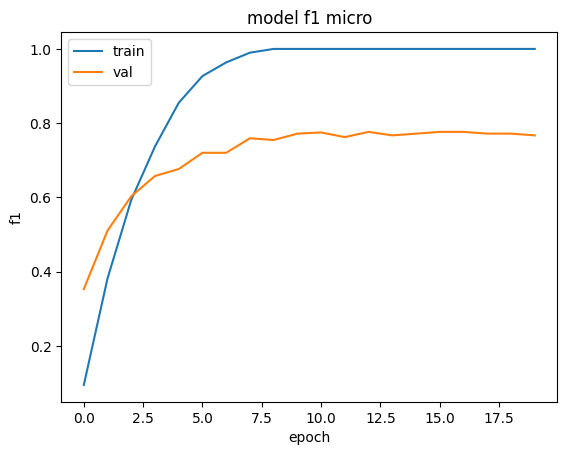

In [19]:
plt.plot(f1s)
plt.plot(f1s_eval)
plt.title('model f1 micro')
plt.ylabel('f1')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [20]:
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=16, shuffle=False)
preds = predict(model, valid_generator)

In [21]:
print(classification_report(valid_targets, preds))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       0.78      0.78      0.78         9
           2       0.90      1.00      0.95         9
           3       0.73      0.89      0.80         9
           4       1.00      1.00      1.00         2
           5       0.78      0.78      0.78         9
           6       0.33      0.40      0.36         5
           7       0.59      0.91      0.71        11
           8       0.73      0.73      0.73        11
           9       0.86      0.75      0.80         8
          10       0.00      0.00      0.00         3
          11       0.67      0.67      0.67         6
          12       1.00      1.00      1.00         1
          13       1.00      0.82      0.90        11
          14       1.00      0.73      0.84        11
          15       1.00      0.33      0.50         3
          16       0.67      0.67      0.67         6

    accuracy              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Итоги:**
Ожидаемо англоязычная модель справляется хуже, чем русскоязычная. При этом усреднение по всем токенам работает лучше, чем [CSL]. Возможно, можно значительно улучшить качество обучения за счет уменьшения learning rate в ранних примерах, так как его изменение в последнем эксперименте дало значительный прирост в качестве (при изначальном значении обучение вообще не шло)